# Práctica - Clase 2: Aprendizaje Automático

## Ejercicio 1: Importación y Manipulación de Datos con PANDAS

### 1. Generación de los archivos de prueba
Generamos los archivos ventas.csv, clientes.json e inventario.xlsx:

In [33]:
import pandas as pd
import json

# 1. generar ventas.csv
df_ventas = pd.DataFrame({
    'id_venta': [1, 2, 3, 4, 5],
    'id_cliente': [1, 2, 1, 3, 2],
    'producto': ['Notebook', 'Mouse', 'Teclado', 'Monitor', 'Impresora'],
    'cantidad': [2, 10, 5, 1, 6],
    'precio_unitario': [1200000.0, 25000.0, 45000.0, 300000.0, 150000.0]
})
df_ventas.to_csv('ventas.csv', index=False)

# 2. generar clientes.json
clientes = [
    {'id_cliente': 1, 'nombre': 'Ana', 'edad': 30, 'email': 'ana@mail.com'},
    {'id_cliente': 2, 'nombre': 'Juan', 'edad': 35, 'email': 'juan@mail.com'},
    {'id_cliente': 3, 'nombre': 'Luis', 'edad': 40, 'email': 'luis@mail.com'}
]
with open('clientes.json', 'w', encoding='utf-8') as f:
    json.dump(clientes, f, ensure_ascii=False, indent=2)

# 3. generar inventario.xlsx
df_inventario = pd.DataFrame({
    'producto': ['Notebook', 'Mouse', 'Teclado', 'Monitor', 'Impresora'],
    'stock_disponible': [15, 100, 50, 10, 8]
})
df_inventario.to_excel('inventario.xlsx', index=False)

print("Los 3 archivos (ventas.csv, clientes.json, inventario.xlsx) fueron generados con éxito.")

Los 3 archivos (ventas.csv, clientes.json, inventario.xlsx) fueron generados con éxito.


### 2. Importación y Operaciones con Pandas

A continuación, realizamos las acciones solicitadas:
1. Cargar datos de ventas desde el archivo CSV y mostrar una vista previa.
2. Cargar datos de clientes desde el archivo JSON y mostrar la cantidad total de clientes.
3. Cargar datos de inventario desde el archivo Excel y calcular el promedio de stock disponible.
4. Combinar las fuentes en una estructura de datos unificada.

In [34]:
# 1. cargar los datos de ventas desde el archivo CSV y mostrar vista previa
ventas = pd.read_csv('ventas.csv')
print("--- 1. Vista previa de ventas (CSV) ---")
display(ventas.head())

# 2. cargar los datos de clientes desde el archivo JSON y mostrar cantidad total de clientes
clientes_df = pd.read_json('clientes.json')
print("\n--- 2. Clientes (JSON) ---")
print(f"Cantidad total de clientes: {len(clientes_df)}")
display(clientes_df)

# 3. cargar los datos de inventario desde excel y calcular el promedio de stock disponible
inventario = pd.read_excel('inventario.xlsx')
promedio_stock = inventario['stock_disponible'].mean()
print("\n--- 3. Inventario (Excel) ---")
print(f"Promedio de stock disponible: {promedio_stock:.2f}")
display(inventario)

# 4. combinar los datasets en una estructura unificada
ventas_completas = ventas.merge(clientes_df, on='id_cliente', how='left')
ventas_completas = ventas_completas.merge(inventario, on='producto', how='left')
print("\n--- Estructura Combinada Final ---")
display(ventas_completas)

--- 1. Vista previa de ventas (CSV) ---


,id_venta,id_cliente,producto,cantidad,precio_unitario
0,1,1,Notebook,2,1200000.0
1,2,2,Mouse,10,25000.0
2,3,1,Teclado,5,45000.0
3,4,3,Monitor,1,300000.0
4,5,2,Impresora,6,150000.0



--- 2. Clientes (JSON) ---
Cantidad total de clientes: 3


,id_cliente,nombre,edad,email
0,1,Ana,30,ana@mail.com
1,2,Juan,35,juan@mail.com
2,3,Luis,40,luis@mail.com



--- 3. Inventario (Excel) ---
Promedio de stock disponible: 36.60


,producto,stock_disponible
0,Notebook,15
1,Mouse,100
2,Teclado,50
3,Monitor,10
4,Impresora,8



--- Estructura Combinada Final ---


,id_venta,id_cliente,producto,cantidad,precio_unitario,nombre,edad,email,stock_disponible
0,1,1,Notebook,2,1200000.0,Ana,30,ana@mail.com,15
1,2,2,Mouse,10,25000.0,Juan,35,juan@mail.com,100
2,3,1,Teclado,5,45000.0,Ana,30,ana@mail.com,50
3,4,3,Monitor,1,300000.0,Luis,40,luis@mail.com,10
4,5,2,Impresora,6,150000.0,Juan,35,juan@mail.com,8


## Ejercicio 2: Inspección y Visualización de Datos con Matplotlib a partir de 'Automobile.csv'

In [35]:
import matplotlib.pyplot as plt

# 1. cargar el conjunto de datos en una estructura adecuada
automobile = pd.read_csv('Automobile.csv')
print('Dimensiones del dataset:', automobile.shape)
display(automobile.head())


Dimensiones del dataset: (398, 9)


,name,mpg,cylinders,displacement,horsepower,weight,acceleration,model_year,origin
0,chevrolet chevelle malibu,18.0,8,307.0,130.0,3504,12.0,70,usa
1,buick skylark 320,15.0,8,350.0,165.0,3693,11.5,70,usa
2,plymouth satellite,18.0,8,318.0,150.0,3436,11.0,70,usa
3,amc rebel sst,16.0,8,304.0,150.0,3433,12.0,70,usa
4,ford torino,17.0,8,302.0,140.0,3449,10.5,70,usa


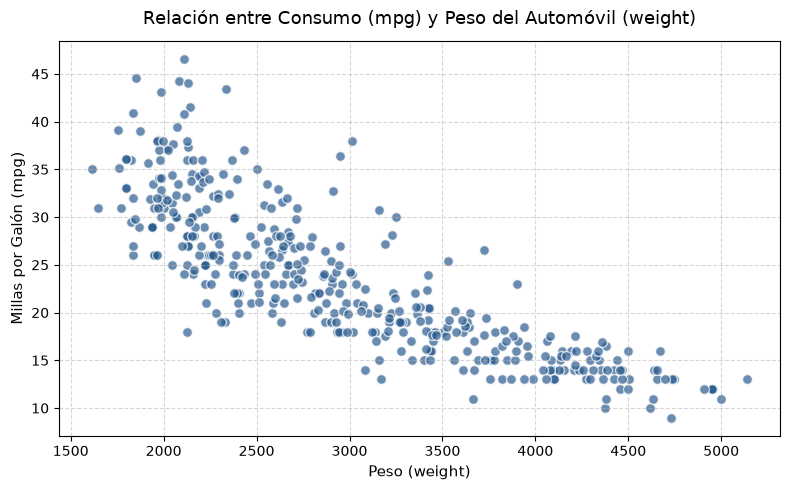

In [36]:
# 2. grafico de dispersion para relaciones numericas entre mpg y weight
plt.figure(figsize=(8, 5))
plt.scatter(automobile['weight'], automobile['mpg'], color='#2b5c8f', alpha=0.7, edgecolors='w', s=50)
plt.title('Relación entre Consumo (mpg) y Peso del Automóvil (weight)', fontsize=13, pad=12)
plt.xlabel('Peso (weight)', fontsize=11)
plt.ylabel('Millas por Galón (mpg)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()


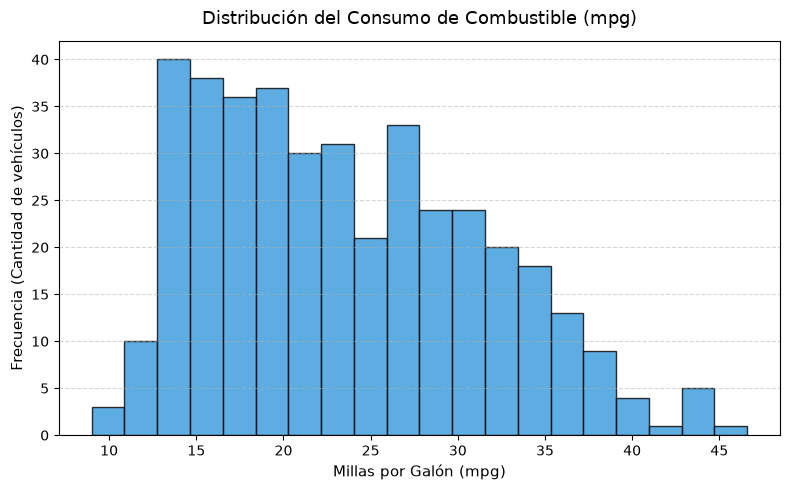

In [37]:
# 3. histograma del consumo de combustible mpg para analizar su distribucion
plt.figure(figsize=(8, 5))
plt.hist(automobile['mpg'].dropna(), bins=20, color='#3498db', edgecolor='black', alpha=0.8)
plt.title('Distribución del Consumo de Combustible (mpg)', fontsize=13, pad=12)
plt.xlabel('Millas por Galón (mpg)', fontsize=11)
plt.ylabel('Frecuencia (Cantidad de vehículos)', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()


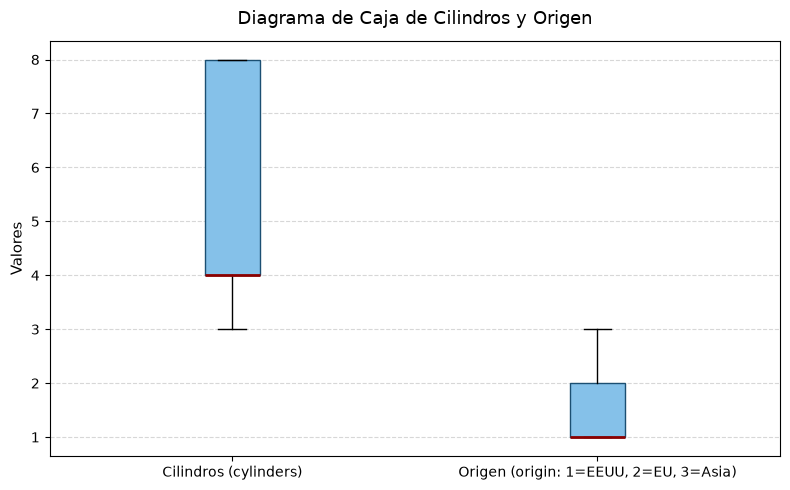

In [38]:
# 4. diagrama de caja (boxplot) de cylinders y origin para identificar valores atipicos
mapeo_origen = {'usa': 1, 'europe': 2, 'japan': 3, 'asia': 3}
origin_num = automobile['origin'].astype(str).str.lower().map(mapeo_origen).fillna(pd.to_numeric(automobile['origin'], errors='coerce'))
cylinders_num = pd.to_numeric(automobile['cylinders'], errors='coerce')

plt.figure(figsize=(8, 5))
box_data = [cylinders_num.dropna(), origin_num.dropna()]
plt.boxplot(box_data, patch_artist=True, boxprops=dict(facecolor='#85c1e9', color='#1b4f72'), medianprops=dict(color='darkred', linewidth=2))
plt.xticks([1, 2], ['Cilindros (cylinders)', 'Origen (origin: 1=EEUU, 2=EU, 3=Asia)'], fontsize=10)
plt.title('Diagrama de Caja de Cilindros y Origen', fontsize=13, pad=12)
plt.ylabel('Valores', fontsize=11)
plt.grid(True, linestyle='--', alpha=0.5, axis='y')
plt.tight_layout()
plt.show()


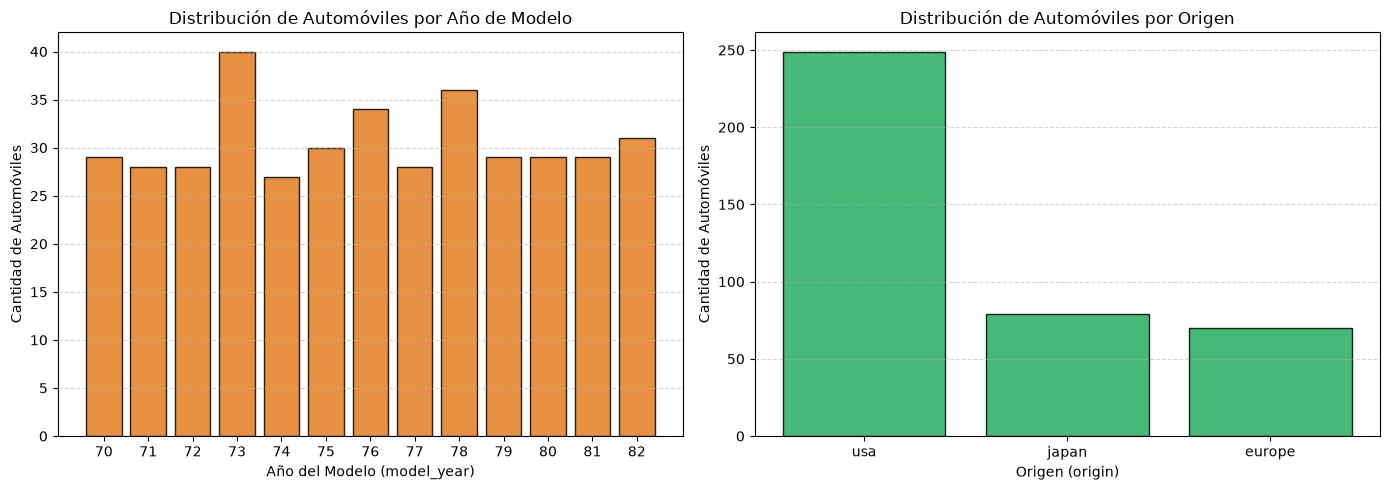

In [39]:
# 5. grafico de barras que muestre la distribucion segun 'model_year' y 'origin'
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# distribucion por Año de Modelo
autos_por_anio = automobile['model_year'].value_counts().sort_index()
axes[0].bar(autos_por_anio.index.astype(str), autos_por_anio.values, color='#e67e22', edgecolor='black', alpha=0.85)
axes[0].set_title('Distribución de Automóviles por Año de Modelo', fontsize=12)
axes[0].set_xlabel('Año del Modelo (model_year)', fontsize=10)
axes[0].set_ylabel('Cantidad de Automóviles', fontsize=10)
axes[0].grid(True, linestyle='--', alpha=0.5, axis='y')

# distribucion por Origen
autos_por_origen = automobile['origin'].value_counts()
axes[1].bar(autos_por_origen.index.astype(str), autos_por_origen.values, color='#27ae60', edgecolor='black', alpha=0.85)
axes[1].set_title('Distribución de Automóviles por Origen', fontsize=12)
axes[1].set_xlabel('Origen (origin)', fontsize=10)
axes[1].set_ylabel('Cantidad de Automóviles', fontsize=10)
axes[1].grid(True, linestyle='--', alpha=0.5, axis='y')

plt.tight_layout()
plt.show()


### 3. Análisis Estadístico Numérico

Para respaldar las observaciones visuales de los gráficos anteriores, realizamos un cálculo exacto de las métricas descriptivas clave utilizando pandas:
1. **Correlación:** Para medir matemáticamente el impacto del peso sobre el consumo.
2. **Asimetría y Tendencia Central:** Para validar la distribución de los galones por milla (mpg).
3. **Cuartiles:** Para entender la estructura subyacente del diagrama de caja de los cilindros.
4. **Frecuencias:** Para obtener el número exacto de vehículos por país y año.

In [40]:
# calcular correlacion de Pearson
correlation = automobile['mpg'].corr(automobile['weight'])
print("--- 1. Correlación entre MPG y Peso ---")
print(f"Coeficiente: {correlation:.4f} (Correlación negativa fuerte)\n")

# calcular metricas del consumo de combustible
mpg_stats = automobile['mpg'].describe()
mpg_skew = automobile['mpg'].skew()
print("--- 2. Estadísticas de Consumo (MPG) ---")
print(f"Media: {mpg_stats['mean']:.2f}")
print(f"Mediana: {mpg_stats['50%']:.2f}")
print(f"Rango: de {mpg_stats['min']} a {mpg_stats['max']} mpg")
print(f"Asimetría (Skewness): {mpg_skew:.4f} (Sesgo positivo/hacia la derecha)\n")

# calcular cuartiles exactos para los cilindros
cyl_stats = automobile['cylinders'].describe()
print("--- 3. Cuartiles de Cilindros (Boxplot) ---")
print(f"Mínimo: {cyl_stats['min']}, Q1: {cyl_stats['25%']}, Mediana: {cyl_stats['50%']}, Q3: {cyl_stats['75%']}, Máximo: {cyl_stats['max']}\n")

# conteo exacto de variables discretas
print("--- 4. Conteo Exacto por Origen ---")
print(automobile['origin'].value_counts(), "\n")

print("--- 5. Conteo Exacto por Año de Modelo ---")
print(automobile['model_year'].value_counts().sort_index())

--- 1. Correlación entre MPG y Peso ---
Coeficiente: -0.8317 (Correlación negativa fuerte)

--- 2. Estadísticas de Consumo (MPG) ---
Media: 23.51
Mediana: 23.00
Rango: de 9.0 a 46.6 mpg
Asimetría (Skewness): 0.4571 (Sesgo positivo/hacia la derecha)

--- 3. Cuartiles de Cilindros (Boxplot) ---
Mínimo: 3.0, Q1: 4.0, Mediana: 4.0, Q3: 8.0, Máximo: 8.0

--- 4. Conteo Exacto por Origen ---
origin
usa       249
japan      79
europe     70
Name: count, dtype: int64 

--- 5. Conteo Exacto por Año de Modelo ---
model_year
70    29
71    28
72    28
73    40
74    27
75    30
76    34
77    28
78    36
79    29
80    29
81    29
82    31
Name: count, dtype: int64
